In [8]:
import json
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
# --- Load the data ---
enterprise_file = '../enterprise-attack/enterprise-attack.json'

try:
    with open(enterprise_file, 'r') as file:
        data = json.load(file)
except FileNotFoundError:
    print("Error: File not found.")
    exit()
except json.JSONDecodeError:
    print("Error: Malformed JSON.")
    exit()

In [3]:
# --- Dictionaries ---
techniques = {}
tactics = {}
technique_names = {}
tactic_names = {}

In [4]:
# --- Step 1: Collect all techniques and tactics ---
for obj in data["objects"]:
    if obj["type"] == "attack-pattern":
        # Technique or subtechnique
        if obj.get("x_mitre_is_subtechnique") is not None:
            techniques[obj["id"]] = 0
            technique_names[obj["id"]] = obj["name"]
        # Tactic-level (no subtechnique field)
        else:
            tactics[obj["id"]] = 0
            tactic_names[obj["id"]] = obj["name"]

In [5]:
# --- Step 2: Count relationships ---
for obj in data["objects"]:
    if obj["type"] == "relationship":
        src = obj.get("source_ref", "")
        tgt = obj.get("target_ref", "")
        if ("campaign" in src or "intrusion-set" in src):
            # If target is a technique
            if tgt in techniques:
                techniques[tgt] += 1
            # If target is a tactic
            elif tgt in tactics:
                tactics[tgt] += 1


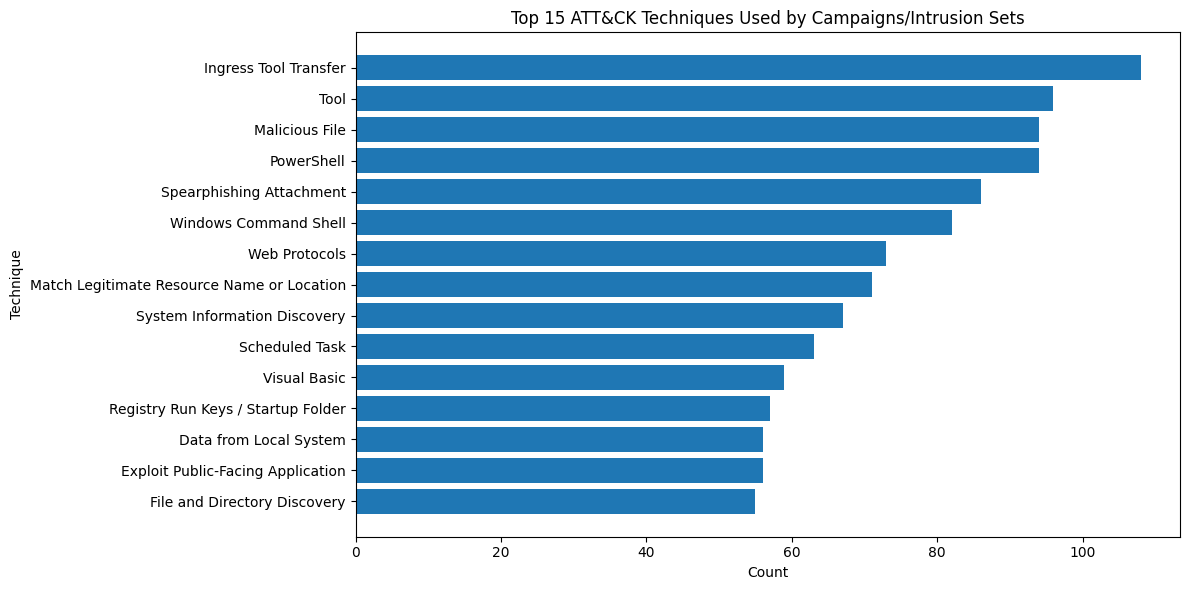

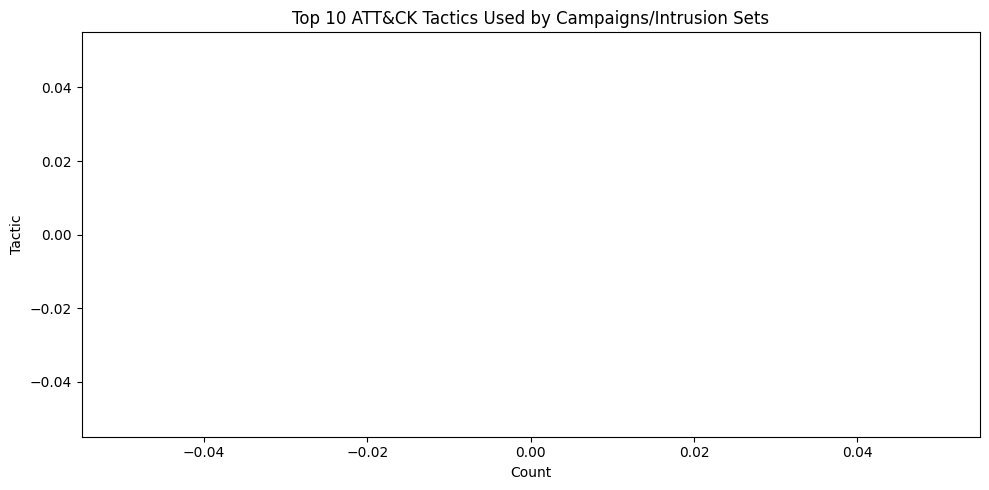

In [6]:

# --- Step 3: Sort for visualization ---
sorted_techniques = sorted(techniques.items(), key=lambda x: x[1], reverse=True)
sorted_tactics = sorted(tactics.items(), key=lambda x: x[1], reverse=True)

# --- Step 4: Create separate plots ---

# Plot 1: Techniques
tech_names = [technique_names[i[0]] for i in sorted_techniques[:15]]
tech_values = [i[1] for i in sorted_techniques[:15]]

plt.figure(figsize=(12, 6))
plt.barh(tech_names[::-1], tech_values[::-1])
plt.xlabel("Count")
plt.ylabel("Technique")
plt.title("Top 15 ATT&CK Techniques Used by Campaigns/Intrusion Sets")
plt.tight_layout()
plt.show()

# Plot 2: Tactics
tac_names = [tactic_names[i[0]] for i in sorted_tactics[:10]]
tac_values = [i[1] for i in sorted_tactics[:10]]

plt.figure(figsize=(10, 5))
plt.barh(tac_names[::-1], tac_values[::-1], color="orange")
plt.xlabel("Count")
plt.ylabel("Tactic")
plt.title("Top 10 ATT&CK Tactics Used by Campaigns/Intrusion Sets")
plt.tight_layout()
plt.show()
